In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print(f"Project root: {ROOT}")

Project root: C:\Users\User HP\Desktop\projekt_garch\.push_repo


In [2]:
import pandas as pd

from garch_btc_sp.models.dcc import DCCModel
from garch_btc_sp.models.univariate_pipeline import fit_univariate_garch
from garch_btc_sp.visualization.plots import (
    plot_all_correlations,
    plot_correlation_heatmap,
    plot_rolling_pearson_comparison,
    plot_time_varying_correlation,
)

In [3]:
# Fit univariate GARCH models for all assets
print("Step 1: Fitting univariate GARCH models...")
standardized_residuals, conditional_volatility = fit_univariate_garch(ROOT)
print(f"Residuals shape: {standardized_residuals.shape}\n")

Step 1: Fitting univariate GARCH models...
Fitting univariate GARCH for BTC...


Fitting univariate GARCH for SP500...


Fitting univariate GARCH for VIX...


Fitting univariate GARCH for OIL...


Fitting univariate GARCH for GOLD...


Standardized residuals shape: (2932, 5)
Conditional volatility shape: (2932, 5)
Residuals shape: (2932, 5)



In [4]:
# Fit DCC-GARCH model
print("Step 2: Fitting DCC-GARCH model...")
dcc = DCCModel(std_residuals=standardized_residuals)
dcc.fit()

summary = dcc.summary()
print("DCC Parameters:")
for key, value in summary.items():
    print(f"  {key}: {value}\n")

Step 2: Fitting DCC-GARCH model...


DCC Parameters:
  alpha: 0.02370211949767278

  beta: 0.9530961324583181

  alpha_plus_beta: 0.9767982519559909

  num_assets: 5

  num_obs: 2932

  optimization_success: True

  optimization_message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH



In [5]:
# Get main correlation: BTC vs SP500
print("Step 3: Extracting BTC-SP500 correlation...")
btc_sp500 = dcc.get_correlation("BTC", "SP500")
print(f"Mean correlation: {btc_sp500.mean():.4f}")
print(f"Min correlation: {btc_sp500.min():.4f}")
print(f"Max correlation: {btc_sp500.max():.4f}\n")
print(btc_sp500.head(10))

Step 3: Extracting BTC-SP500 correlation...
Mean correlation: 0.1920
Min correlation: -0.1362
Max correlation: 0.4923

Date
2014-09-18    0.194673
2014-09-19    0.171572
2014-09-22    0.171153
2014-09-23    0.162723
2014-09-24    0.138581
2014-09-25    0.130207
2014-09-26    0.146275
2014-09-29    0.141434
2014-09-30    0.147596
2014-10-01    0.145026
Name: BTC-SP500, dtype: float64


Step 4: Generating visualizations...



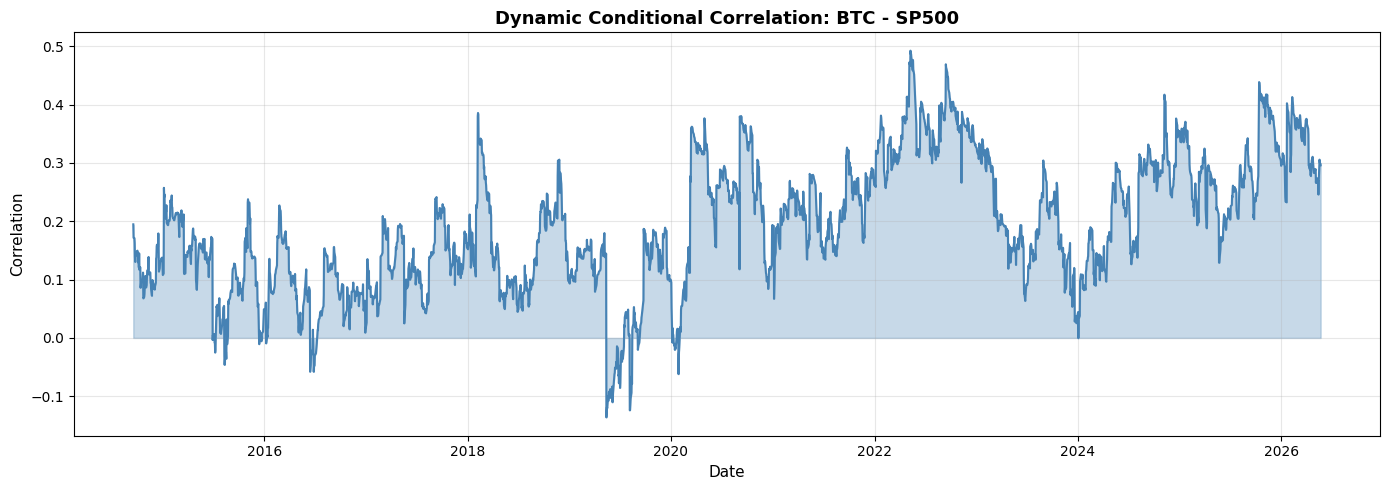

In [6]:
# Generate visualizations
print("Step 4: Generating visualizations...\n")

# Main plot: BTC-SP500 time-varying correlation
plot_time_varying_correlation(dcc, asset1="BTC", asset2="SP500")

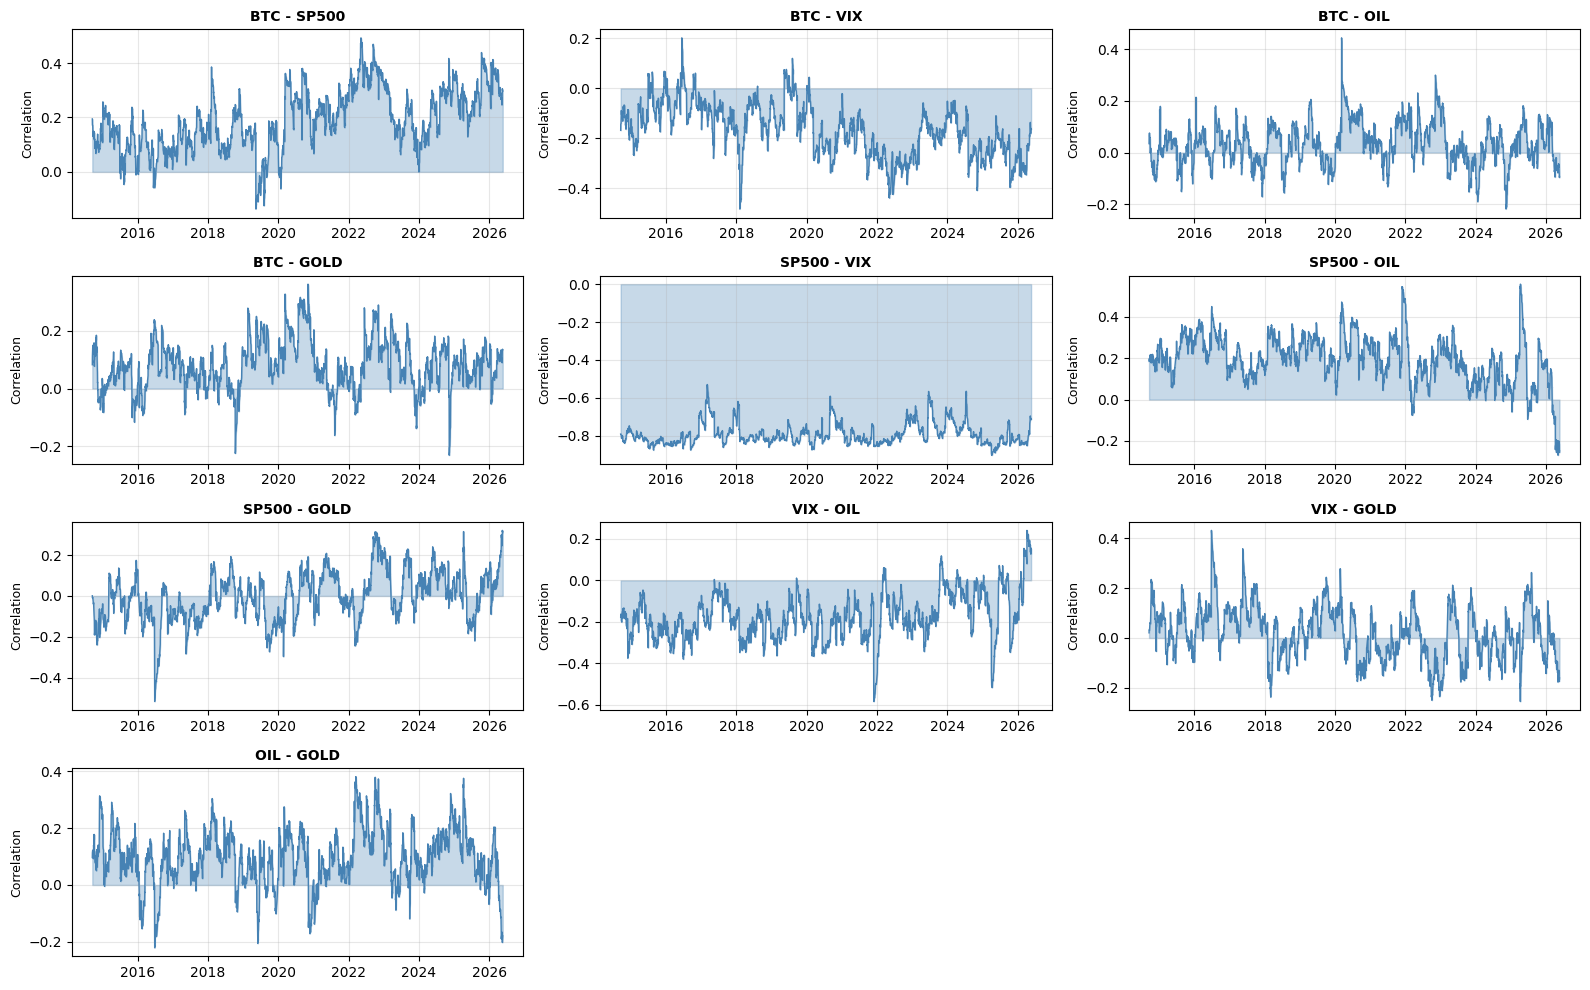

In [7]:
# All pairwise correlations
plot_all_correlations(dcc)

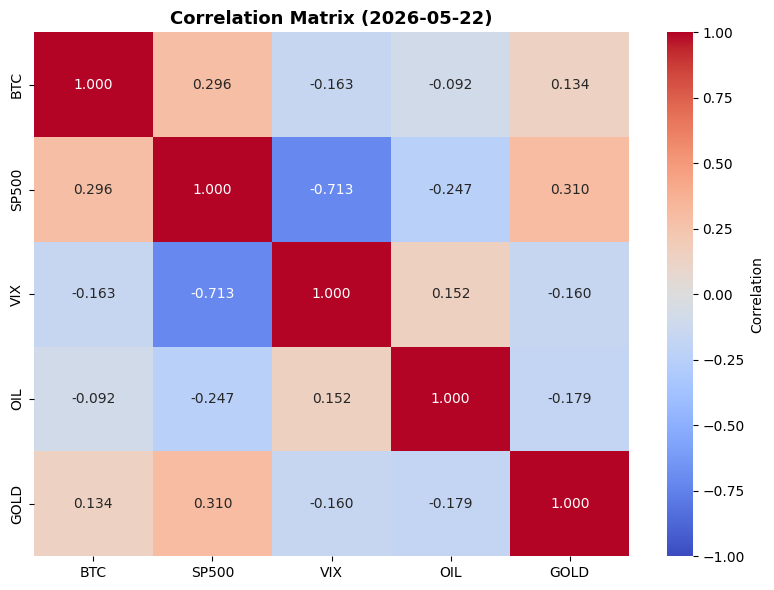

In [8]:
# Correlation heatmap at most recent date
plot_correlation_heatmap(dcc, period="all")

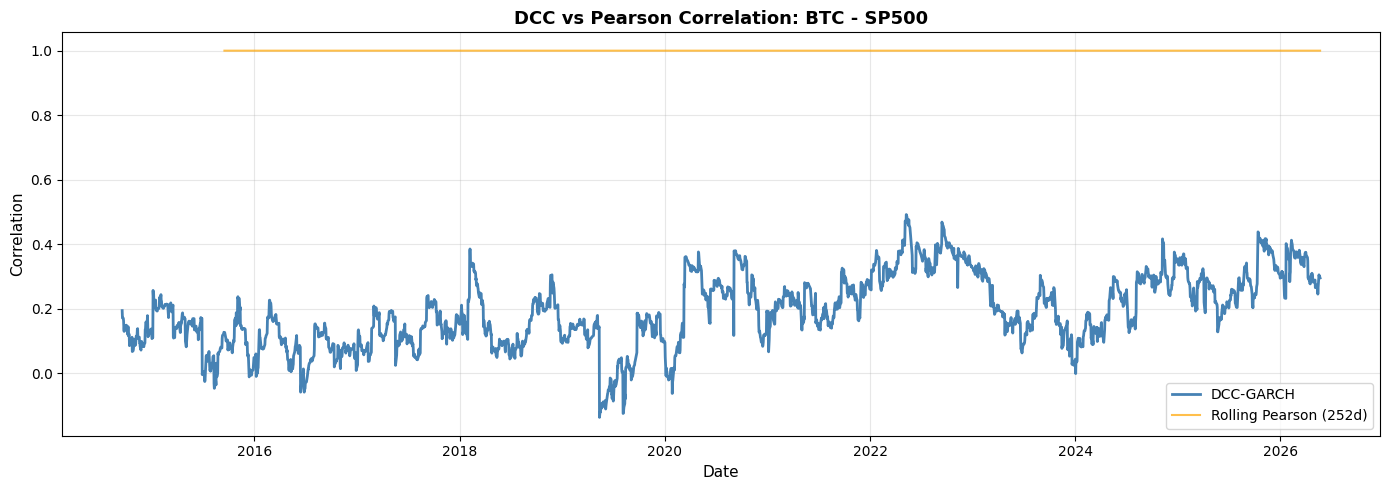

In [9]:
# DCC vs rolling Pearson comparison
plot_rolling_pearson_comparison(
    standardized_residuals, 
    dcc, 
    asset1="BTC", 
    asset2="SP500", 
    window=252
)

In [10]:
# Save main results for report integration
print("Step 5: Saving results for report...")
output_dir = ROOT / "outputs"
output_dir.mkdir(exist_ok=True)

btc_sp500.to_csv(output_dir / "btc_sp500_dcc_correlation.csv")
print(f"Saved: {output_dir / 'btc_sp500_dcc_correlation.csv'}")

# Save DCC model results
dcc_summary_df = pd.DataFrame([summary])
dcc_summary_df.to_csv(output_dir / "dcc_parameters.csv", index=False)
print(f"Saved: {output_dir / 'dcc_parameters.csv'}")

# Save all correlations
for (asset1, asset2), corr_series in dcc.time_varying_corr.items():
    filename = f"{asset1}_{asset2}_correlation.csv"
    corr_series.to_csv(output_dir / filename)
    print(f"Saved: {output_dir / filename}")

Step 5: Saving results for report...
Saved: C:\Users\User HP\Desktop\projekt_garch\.push_repo\outputs\btc_sp500_dcc_correlation.csv
Saved: C:\Users\User HP\Desktop\projekt_garch\.push_repo\outputs\dcc_parameters.csv
Saved: C:\Users\User HP\Desktop\projekt_garch\.push_repo\outputs\BTC_SP500_correlation.csv
Saved: C:\Users\User HP\Desktop\projekt_garch\.push_repo\outputs\BTC_VIX_correlation.csv
Saved: C:\Users\User HP\Desktop\projekt_garch\.push_repo\outputs\BTC_OIL_correlation.csv
Saved: C:\Users\User HP\Desktop\projekt_garch\.push_repo\outputs\BTC_GOLD_correlation.csv
Saved: C:\Users\User HP\Desktop\projekt_garch\.push_repo\outputs\SP500_VIX_correlation.csv
Saved: C:\Users\User HP\Desktop\projekt_garch\.push_repo\outputs\SP500_OIL_correlation.csv
Saved: C:\Users\User HP\Desktop\projekt_garch\.push_repo\outputs\SP500_GOLD_correlation.csv
Saved: C:\Users\User HP\Desktop\projekt_garch\.push_repo\outputs\VIX_OIL_correlation.csv
Saved: C:\Users\User HP\Desktop\projekt_garch\.push_repo\outpu